/tmp/ipykernel_58/1324157748.py:18: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inp)
I0000 00:00:1785639744.299352      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785639744.302351      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Epoch 1/30


2026-08-02 03:02:52.891554: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 03:02:53.029407: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1785639780.029931     130 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


140/140 ━━━━━━━━━━━━━━━━━━━━ 131s 721ms/step - accuracy: 0.7569 - loss: 0.7222 - val_accuracy: 0.6982 - val_loss: 0.8020 - learning_rate: 1.0000e-04
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 516ms/step - accuracy: 0.8833 - loss: 0.3330 - val_accuracy: 0.7607 - val_loss: 0.6556 - learning_rate: 1.0000e-04
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 508ms/step - accuracy: 0.9163 - loss: 0.2311 - val_accuracy: 0.8098 - val_loss: 0.6633 - learning_rate: 1.0000e-04
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 514ms/step - accuracy: 0.9388 - loss: 0.1637 - val_accuracy: 0.8500 - val_loss: 0.4879 - learning_rate: 1.0000e-04
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 510ms/step - accuracy: 0.9565 - loss: 0.1281 - val_accuracy: 0.8438 - val_loss: 0.6120 - learning_rate: 1.0000e-04
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 70s 503ms/step - accuracy: 0.9583 - loss: 0.1164 - val_accuracy: 0.8929 - val_loss: 0.4117 - learning_rate: 1.0000e-04
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 508ms/step -

/tmp/ipykernel_58/1324157748.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(class_entropy, labels=class_names, patch_artist=True)


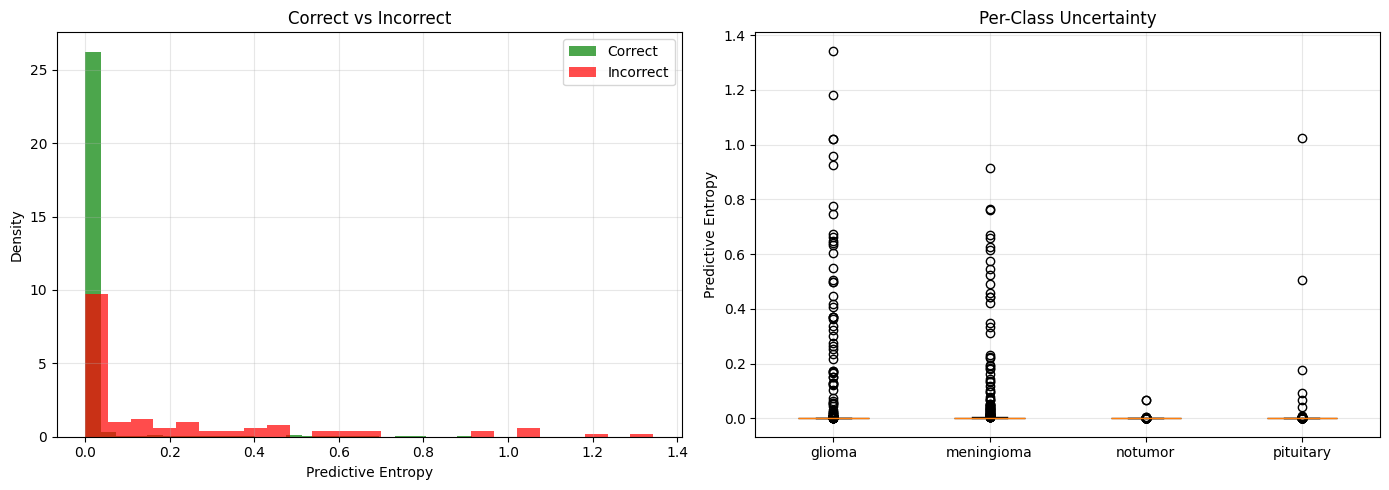


Mean entropy (correct): 0.0119
Mean entropy (incorrect): 0.2088
glioma: 0.0526
meningioma: 0.0342
notumor: 0.0004
pituitary: 0.0049

✅ DONE. Download uncertainty_analysis.png


In [1]:
import os, numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as pre
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns

BASE = '/kaggle/input/datasets/ekrasafdar/brain-tumor-mri'
TRAIN_DIR = os.path.join(BASE, 'Training')
TEST_DIR  = os.path.join(BASE, 'Testing')

# Build MC Dropout model
tf.random.set_seed(42); np.random.seed(42)
inp = layers.Input(shape=(224, 224, 3))
base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inp)
base.trainable = True
for L in base.layers[:-50]: L.trainable = False
x = layers.GlobalAveragePooling2D()(base.output)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x, training=True)  # MC Dropout
out = layers.Dense(4, activation='softmax')(x)
model = keras.Model(inp, out)
model.compile(optimizer=keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Data
tr_aug = ImageDataGenerator(preprocessing_function=pre, rotation_range=20,
    width_shift_range=0.15, height_shift_range=0.15, zoom_range=0.15,
    horizontal_flip=True, brightness_range=[0.8, 1.2], validation_split=0.2)
tr = tr_aug.flow_from_directory(TRAIN_DIR, target_size=(224,224), batch_size=32,
    class_mode='categorical', subset='training', seed=42)
val = tr_aug.flow_from_directory(TRAIN_DIR, target_size=(224,224), batch_size=32,
    class_mode='categorical', subset='validation', shuffle=False, seed=42)
te = ImageDataGenerator(preprocessing_function=pre).flow_from_directory(
    TEST_DIR, target_size=(224,224), batch_size=32, class_mode='categorical', shuffle=False)

# Train
cb = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
]
model.fit(tr, validation_data=val, epochs=30, callbacks=cb, verbose=1)

# Eval
te.reset(); loss, acc = model.evaluate(te, verbose=0)
te.reset(); yp = np.argmax(model.predict(te, verbose=0), axis=1)
yt = te.classes
print(f"\nMC Model — Accuracy: {acc*100:.2f}% | F1: {f1_score(yt, yp, average='weighted')*100:.2f}%")

# Uncertainty (MC Dropout inference)
print("\nRunning MC Dropout uncertainty...")
te.reset()
all_preds = []
for _ in range(50):
    te.reset()
    all_preds.append(model.predict(te, verbose=0))
all_preds = np.array(all_preds)
mean_pred = np.mean(all_preds, axis=0)
entropy = -np.sum(mean_pred * np.log(mean_pred + 1e-10), axis=1)
y_true = te.classes
y_pred = np.argmax(mean_pred, axis=1)
correct = (y_true == y_pred)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(entropy[correct], bins=25, alpha=0.7, label='Correct', color='green', density=True)
axes[0].hist(entropy[~correct], bins=25, alpha=0.7, label='Incorrect', color='red', density=True)
axes[0].set_xlabel('Predictive Entropy'); axes[0].set_ylabel('Density')
axes[0].set_title('Correct vs Incorrect'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
class_entropy = [entropy[y_true == i] for i in range(4)]
bp = axes[1].boxplot(class_entropy, labels=class_names, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_ylabel('Predictive Entropy'); axes[1].set_title('Per-Class Uncertainty')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/uncertainty_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Stats
print(f"\nMean entropy (correct): {np.mean(entropy[correct]):.4f}")
print(f"Mean entropy (incorrect): {np.mean(entropy[~correct]):.4f}")
for i, name in enumerate(class_names):
    print(f"{name}: {np.mean(entropy[y_true == i]):.4f}")

print("\n✅ DONE. Download uncertainty_analysis.png")

In [ ]:
import os, numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as pre
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

BASE = '/kaggle/input/datasets/ekrasafdar/brain-tumor-mri'
TRAIN_DIR = os.path.join(BASE, 'Training')
FIGSHARE_DIR = '/kaggle/input/YOUR_FIGSHARE_PATH'  # Update this

# Rebuild best MobileNetV2 (seed 42)
tf.random.set_seed(42); np.random.seed(42)
inp = layers.Input(shape=(224, 224, 3))
base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inp)
base.trainable = True
for L in base.layers[:-50]: L.trainable = False
x = layers.GlobalAveragePooling2D()(base.output)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(4, activation='softmax')(x)
model = keras.Model(inp, out)
model.compile(optimizer=keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Train
tr_aug = ImageDataGenerator(preprocessing_function=pre, rotation_range=20,
    width_shift_range=0.15, height_shift_range=0.15, zoom_range=0.15,
    horizontal_flip=True, brightness_range=[0.8, 1.2], validation_split=0.2)
tr = tr_aug.flow_from_directory(TRAIN_DIR, target_size=(224,224), batch_size=32,
    class_mode='categorical', subset='training', seed=42)
val = tr_aug.flow_from_directory(TRAIN_DIR, target_size=(224,224), batch_size=32,
    class_mode='categorical', subset='validation', shuffle=False, seed=42)
cb = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
]
model.fit(tr, validation_data=val, epochs=30, callbacks=cb, verbose=1)

# Evaluate on Figshare
fig_gen = ImageDataGenerator(preprocessing_function=pre).flow_from_directory(
    FIGSHARE_DIR, target_size=(224,224), batch_size=32, class_mode='categorical', shuffle=False)
fig_gen.reset(); yp = np.argmax(model.predict(fig_gen, verbose=0), axis=1)
yt = fig_gen.classes

cm = confusion_matrix(yt, yp)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['glioma','meningioma','pituitary'],
    yticklabels=['glioma','meningioma','pituitary'])
plt.title('Cross-Dataset Confusion Matrix (MobileNetV2 → Figshare)')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/kaggle/working/cross_dataset_cm.png', dpi=300)
plt.show()

/tmp/ipykernel_58/2665437368.py:18: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inp)


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 96s 547ms/step - accuracy: 0.7437 - loss: 0.7168 - val_accuracy: 0.7732 - val_loss: 0.6051 - learning_rate: 1.0000e-04
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 509ms/step - accuracy: 0.8846 - loss: 0.3279 - val_accuracy: 0.8214 - val_loss: 0.5660 - learning_rate: 1.0000e-04
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 512ms/step - accuracy: 0.9167 - loss: 0.2375 - val_accuracy: 0.8580 - val_loss: 0.4762 - learning_rate: 1.0000e-04
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 509ms/step - accuracy: 0.9357 - loss: 0.1848 - val_accuracy: 0.8884 - val_loss: 0.3143 - learning_rate: 1.0000e-04
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 506ms/step - accuracy: 0.9533 - loss: 0.1327 - val_accuracy: 0.9223 - val_loss: 0.2687 - learning_rate: 1.0000e-04
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 505ms/step - accuracy: 0.9625 - loss: 0.1116 - val_accuracy: 0.8652 - val_los